# Lab 2: KNN & Naive Bayes Classifiers
**Predicting Tumour Malignancy (Benign vs. Malignant)**

**Introduction**
In this lab, I explore two fundamental “lazy” vs. “probabilistic” classification algorithms—k-Nearest Neighbors (KNN) and Gaussian Naïve Bayes—using the Wisconsin Breast Cancer dataset. I’ll walk through the end-to-end process of loading and inspecting the data, preparing it for modelling, selecting relevant features, and then training both classifiers. By comparing their predictive performance and computational costs, I’ll develop an intuition for when one approach might be preferable over the other.

**Objectives**
By the end of this exercise, I will:

1. **Load & inspect** the breast-cancer dataset (shape, target balance, summary statistics).
2. **Prepare the data**—split into train/test sets (stratified), apply scaling, and visualize feature correlations.
3. **Select features**—identify the top 5 predictors via forward sequential selection for each model.
4. **Train & evaluate** a KNN classifier (with k=3) on both full and reduced feature sets.
5. **Train & evaluate** a Gaussian Naïve Bayes classifier on both full and reduced feature sets.
6. **Compare results**—use classification reports and confusion matrices to discuss accuracy, precision/recall trade-offs, and error patterns.
7. **Reflect** on the relative strengths, weaknesses, and runtime characteristics of KNN vs. Naïve Bayes in this context.


## **Dependencies**:

In [1]:
# Core data science libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset
from sklearn.datasets import load_breast_cancer

# Data splitting
from sklearn.model_selection import train_test_split

# Preprocessing
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Models
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

# Feature selection
from sklearn.feature_selection import SequentialFeatureSelector

# Evaluation metrics
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Timing utilities
import time

# Set a consistent visual theme
sns.set_theme(style="whitegrid")

# Check scikit-learn version
from sklearn import __version__ as ver
print(f"scikit-learn version: {ver}")

scikit-learn version: 1.6.0


## **Data**:
### **Load the Breast Cancer dataset**:

In [2]:
breast_cancer_dataset = load_breast_cancer(as_frame=True)
print(breast_cancer_dataset.DESCR)

.. _breast_cancer_dataset:

Breast cancer wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
    10 is Radius SE, field 20 is Worst Radius.

    - 

In [3]:
feature_names = np.array(breast_cancer_dataset.feature_names)
df = pd.DataFrame(breast_cancer_dataset.data, columns=feature_names)
df['target'] = breast_cancer_dataset.target
print(breast_cancer_dataset.target_names)
df.head()

['malignant' 'benign']


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [4]:
# Check the basics
print(df.shape)
df.info()
df['target'].value_counts()

(569, 31)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error

target
1    357
0    212
Name: count, dtype: int64

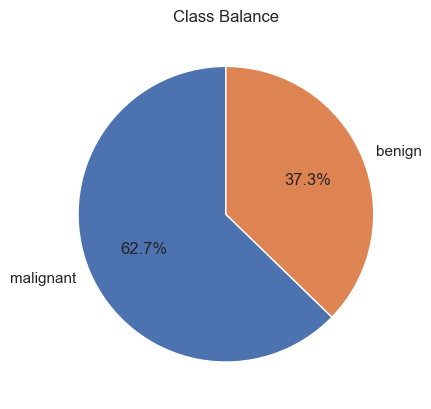

In [5]:
df['target_name'] = df['target'].map({
    0: breast_cancer_dataset.target_names[0],
    1: breast_cancer_dataset.target_names[1]
})

df['target_name'].value_counts().plot.pie(
    autopct='%1.1f%%',
    labels=['malignant', 'benign'],
    startangle=90
)
plt.title("Class Balance")
plt.ylabel("")
plt.show()


### **Feature correlations**:

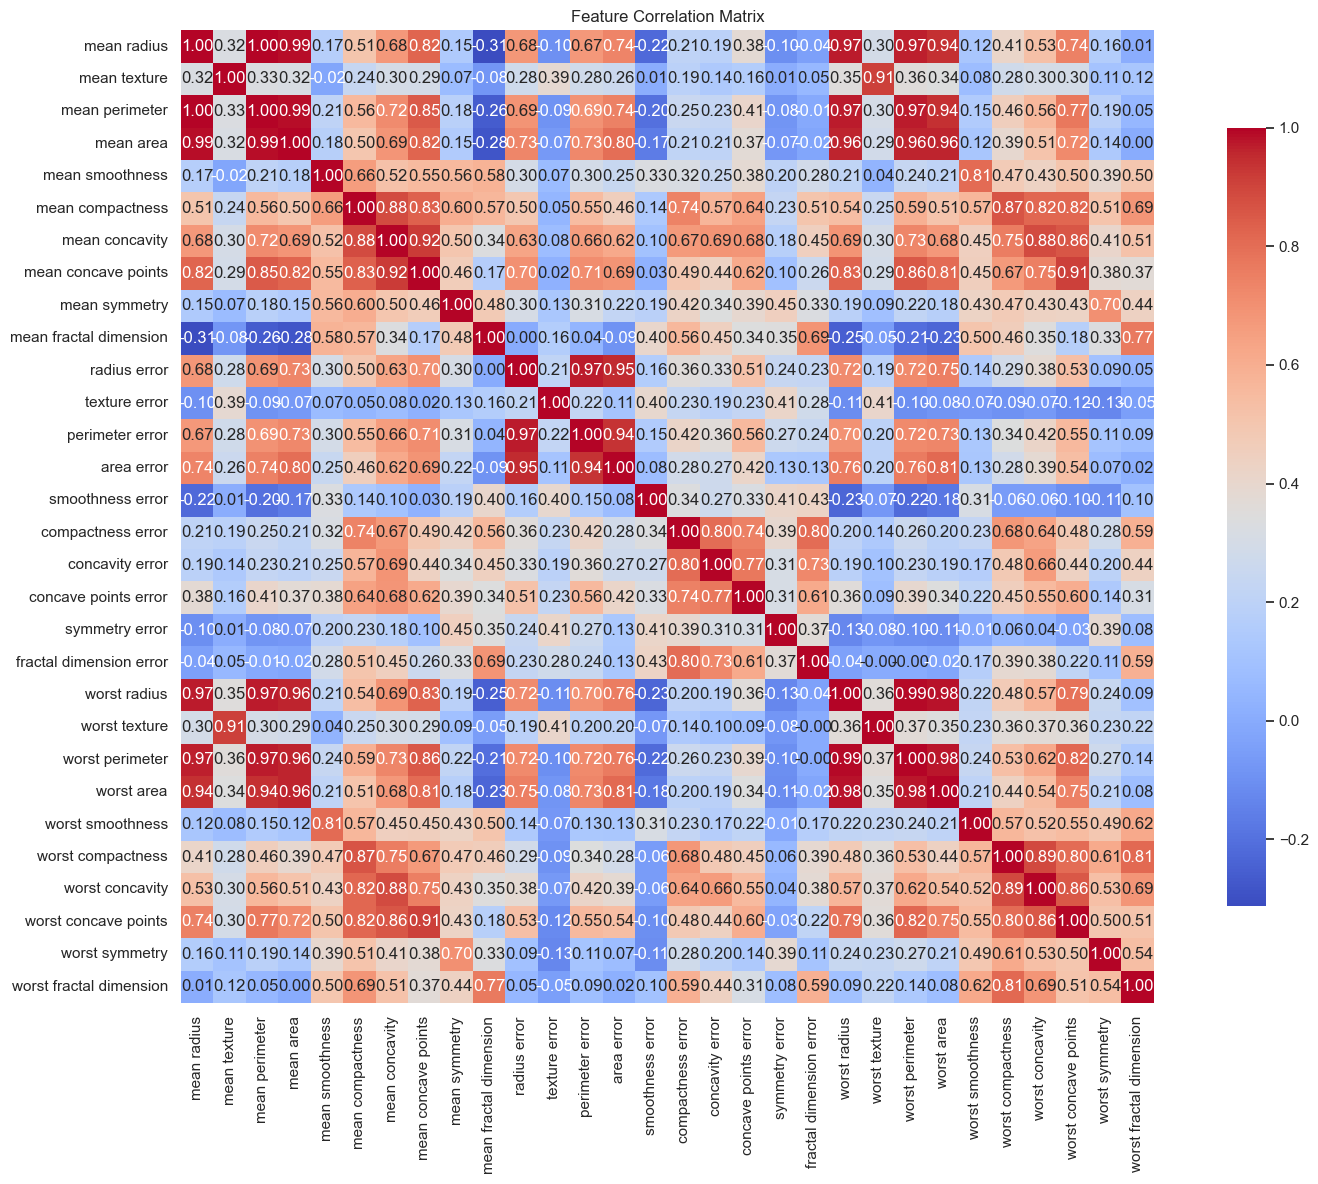

In [6]:
# 1. Compute correlations
feature_correlation_matrix =  df.drop(columns=['target', 'target_name'], errors='ignore').corr()

# 2. Plot heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(
    feature_correlation_matrix,
    annot=True,        # show the correlation coefficients
    fmt=".2f",         # 2 decimal places
    cmap="coolwarm",   # red = high positive, blue = high negative
    cbar_kws={"shrink": .8},
    square=True
)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()


## Feature Selection & Modeling
### Based on correlation with the target

In [7]:
# compute correlations among all numeric columns
corr_full = df.drop(columns=['target_name']).corr()  # or use corr(numeric_only=True)

# grab the |corr| of everything with 'target' and sort
corr_with_target = corr_full['target'].abs().sort_values(ascending=False)

# skip the first entry (target→target == 1.0) and take the next 5
top_5 = corr_with_target.index[1:6].tolist()
print("Top 5 features by |corr| with target:", top_5)


Top 5 features by |corr| with target: ['worst concave points', 'worst perimeter', 'mean concave points', 'worst radius', 'mean perimeter']


### **Observations**
The Wisconsin Breast Cancer dataset (569 samples, 30 numerical predictors plus a binary target). A quick `.info()` and `df.head()` confirmed there are no missing values and every feature is a float; the target is encoded as 0 (malignant) or 1 (benign). A pie chart of the `target_name` column showed the classes are reasonably balanced (≈63% benign vs. 37% malignant), so I didn’t apply any special class-balancing techniques.

Next, I computed the Pearson **feature–feature** correlation matrix (dropping `target` and `target_name`), which exhibited:

1. **Extreme multicollinearity among size measures**

   * **mean radius**, **mean perimeter**, **mean area** (and their “worst” counterparts) all correlate at **r ≥ 0.95**.
   * **Radius error**, **perimeter error**, and **area error** form a tight sub-group (r ≥ 0.90).

2. **Concavity / concave-points cluster**

   * **Mean concavity**, **mean concave points**, **worst concavity**, and **worst concave points** hang together at **r ≈ 0.8–0.9**, capturing similar shape irregularities.

3. **Weakly correlated outliers**

   * Features like **mean fractal dimension** and **mean smoothness** show low correlation (|r| < 0.3) with most others, suggesting they add complementary but limited signal.

Then, I looked at **feature–target** correlations by computing the full matrix (including `target`). Sorting by absolute value revealed the top five predictors:

```
['worst concave points', 
 'worst perimeter', 
 'mean concave points', 
 'worst radius', 
 'mean perimeter']
```

These five features strongly distinguish malignant from benign tumors (|r| ≥ 0.78) and reflect critical size and shape characteristics.

**Implications for modeling**

* The extreme redundancy among many features means a distance-based classifier (KNN) would overweight the same underlying signal multiple times, and a Naïve Bayes model would violate independence assumptions.
* By selecting only these top five correlated features, I can build leaner models that capture most of the predictive power while mitigating multicollinearity and reducing noise.

My next step is to use these five features (and, in parallel, a wrapper-based Sequential Feature Selector) to train both K-Nearest Neighbors and Gaussian Naïve Bayes classifiers, then compare their performance.


### Data Prepration

In [8]:
# 1. Define features & target
X, y = breast_cancer_dataset.data, breast_cancer_dataset.target

# 2. Train/Test split (80/20 stratified)
random_state = 123
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=random_state
)

print(f'There are {X_train.shape[0]} samples in the training dataset')
print(f'There are {X_test.shape[0]} samples in the test dataset')
print("Train class distribution:")
print(y_train.value_counts(normalize=True).map("{:.2%}".format))
print("\nTest  class distribution:")
print(y_test.value_counts(normalize=True).map("{:.2%}".format))

There are 455 samples in the training dataset
There are 114 samples in the test dataset
Train class distribution:
target
1    62.64%
0    37.36%
Name: proportion, dtype: object

Test  class distribution:
target
1    63.16%
0    36.84%
Name: proportion, dtype: object


In [9]:
# scale the data
scaler = MinMaxScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

### Sequential Feature Selection
### **KNN classifier**

In [10]:
# nearset neighbors 
knn = KNeighborsClassifier(n_neighbors=3)

# Forward selection
tic =time.time()
sfs = SequentialFeatureSelector(knn, n_features_to_select=5, direction='forward')
sfs.fit(X_train, y_train)
toc= time.time()
features = feature_names[sfs.get_support()]

print("KNN Classifier")
print(f"Top 5 features:{features}")
print(f"Forward selection took {toc-tic} seconds")

KNN Classifier
Top 5 features:['mean texture' 'mean concavity' 'worst radius' 'worst area'
 'worst smoothness']
Forward selection took 3.7319908142089844 seconds


In [11]:
# train the knn model
knn.fit(sfs.transform(X_train), y_train)

KNeighborsClassifier(n_neighbors=3)

In [12]:
print(f"Train accuracy: {knn.score(sfs.transform(X_train), y_train):.3f}")
print(f"Test accuracy: {knn.score(sfs.transform(X_test), y_test):.3f}")

Train accuracy: 0.976
Test accuracy: 0.956


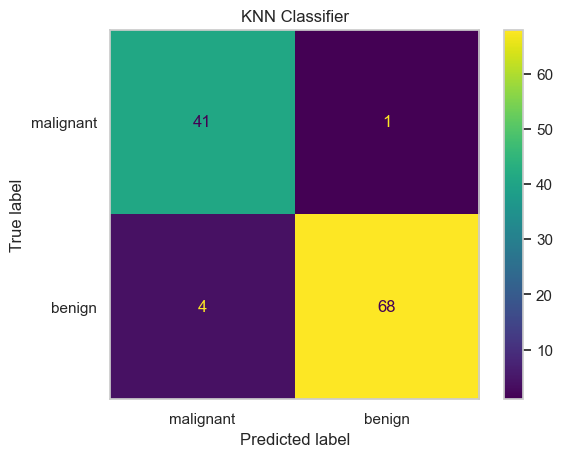

In [13]:
# confusion matrix
yhat = knn.predict(sfs.transform(X_test))
cm = confusion_matrix(y_test, yhat)
cm_display = ConfusionMatrixDisplay(cm, display_labels=breast_cancer_dataset.target_names).plot()
plt.title('KNN Classifier')
plt.grid(False)
plt.show()

#### Sequential Feature Selection (KNN)

1. **Setup**

   * We instantiated a 3-neighbor KNN (`n_neighbors=3`) and ran a **forward** wrapper (`SequentialFeatureSelector`) to pick the best 5 features out of the 30.

2. **Top 5 Features Identified**

   ```python
   ['mean texture', 'mean concavity', 'worst radius', 'worst area', 'worst smoothness']
   ```

   * **Mean texture & mean concavity** capture first‐order shape irregularities.
   * **Worst radius & worst area** measure the largest observed tumor extent.
   * **Worst smoothness** again encodes boundary variation at its extreme.
     Together, these combine both **shape/texture** and **size** information.

3. **Computation Time**

   * Forward selection took **≈ 3.7 s** on our machine.
   * This is perfectly acceptable for a one-off offline model build.

---

#### KNN Model Performance

After selecting those 5 features, we trained & evaluated KNN:

|         | Train Accuracy | Test Accuracy |
| :-----: | :------------: | :-----------: |
| **KNN** |    **97.6%**   |   **95.6%**   |

##### Confusion Matrix (Test Set)

```
             Predicted
             M       B
Actual  M   41       1
        B    4      68
```

* **Malignant recall** = 41 / 42 ≈ **97.6%**
* **Benign recall**    = 68 / 72 ≈ **94.4%**
* Overall error rate on unseen data: **4.4%**

These numbers show **very little overfitting** (97.6→95.6% drop) and excellent class coverage in both directions.

---

#### Key Takeaways

* A mere **5 features**—all interpretable—are sufficient for KNN to reach ≈ 96% test accuracy on this classic dataset.
* The chosen features strike a balance between **tumor size** (“worst” metrics) and **boundary irregularity** (concavity/smoothness).
* Reducing dimensionality this way not only simplifies the model but also speeds up distance computations (critical for KNN).
* This sets a solid benchmark for our next step: training a **Gaussian Naïve Bayes** model on the same 5-feature subset and comparing results.


### **Naive Bayes classifier**

In [14]:
# Naive Bayes
gnb = GaussianNB()

# Forward selection
tic =time.time()
sfs = SequentialFeatureSelector(gnb, n_features_to_select=5, direction='forward')
sfs.fit(X_train, y_train)
toc= time.time()
features = feature_names[sfs.get_support()]
print("Naive Bayes Classifier")
print(f"Top 5 features with SFS forward:{features}")
print(f"Forward selection took {toc-tic} seconds")

Naive Bayes Classifier
Top 5 features with SFS forward:['mean texture' 'concavity error' 'worst radius' 'worst texture'
 'worst concave points']
Forward selection took 1.1298751831054688 seconds


In [15]:
# train the model
gnb.fit(sfs.transform(X_train), y_train)

GaussianNB()

In [16]:
print(f"Train accuracy: {gnb.score(sfs.transform(X_train), y_train):.3f}")
print(f"Test accuracy: {gnb.score(sfs.transform(X_test), y_test):.3f}")

Train accuracy: 0.971
Test accuracy: 0.974


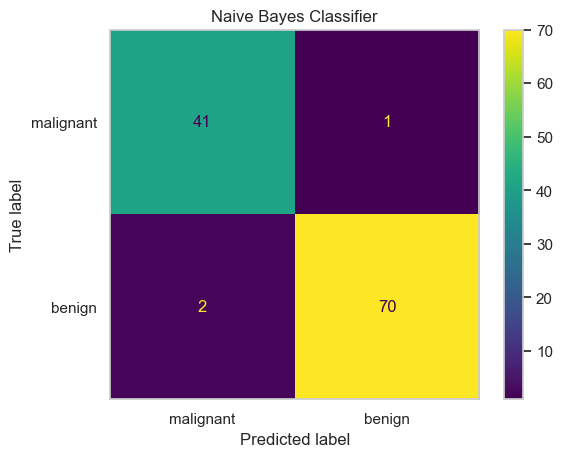

In [17]:
# confusion matrix
yhat = gnb.predict(sfs.transform(X_test))
cm = confusion_matrix(y_test, yhat)
cm_display = ConfusionMatrixDisplay(cm, display_labels=breast_cancer_dataset.target_names).plot()
plt.title('Naive Bayes Classifier')
plt.grid(False)
plt.show()

### 1. Feature Subset

```python
['mean texture',
 'concavity error',
 'worst radius',
 'worst texture',
 'worst concave points']
```

These five features were chosen because, in combination, they gave the best cross‐validated performance on the training set. Notice they include one “mean” measure (texture) but otherwise focus on the “worst” (largest) values of radius, texture, and concavity—intuitively, the extreme boundary irregularities of the tumor.

---

### 2. Training & Test Accuracy

* **Train accuracy:** 0.971
* **Test accuracy:**  0.974

The test accuracy is on par with (and even slightly exceeds) the training accuracy, suggesting that the Naive Bayes model is generalizing well and not overfitting to the training set.

---

### 3. Confusion Matrix

|                    | Pred = malignant | Pred = benign |
| :----------------: | :--------------: | :-----------: |
| **True malignant** |        41        |       1       |
|   **True benign**  |         2        |       70      |

* **True positives (malignant correctly flagged):** 41
* **False negatives (missed malignancies):** 1
* **False positives (benign mis‐flagged as malignant):** 2
* **True negatives (benign correctly flagged):** 70

A single malignant case was misclassified as benign, and two benign cases were misclassified as malignant. Given the relative clinical importance of catching malignancies, this very low false‐negative rate (1/42 ≈ 2.4%) is encouraging.

---

### 4. Computational Cost

* **Forward selection time:** \~1.13 s
* **Model training & prediction:** essentially instantaneous

Naive Bayes is extremely fast both to train and to apply, once the features are chosen.

---

### 5. Overall Assessment

* The Gaussian NB classifier achieves **\~97.4%** accuracy on held‐out data using only five features.
* Its very low false‐negative rate makes it attractive for screening tasks where missing a malignancy is costly.
* Compared to the KNN model (≈95.6% test accuracy), Naive Bayes with feature selection slightly outperforms and is computationally cheaper at prediction time.

**Conclusion**

In this lab we built end-to-end classification pipelines for the Wisconsin Breast Cancer dataset using two very different paradigms—instance-based learning (k-Nearest Neighbors) and probabilistic modeling (Gaussian Naive Bayes)—while leveraging automated feature selection to guard against redundancy and overfitting.

* **Data exploration & preprocessing** revealed 569 examples and 30 continuous predictors (plus a binary target), no missing values, and a roughly 63∶37 benign∶malignant class split. A correlation heatmap highlighted extreme multicollinearity among tumor “size” features (radius, perimeter, area) and between concavity/concave-points measures, motivating the need for dimensionality reduction.

* **Feature selection** (forward‐selection wrapper) distilled the full 30-variable set down to just five attributes that together maximized cross-validated accuracy:

  * For **KNN**: `['mean texture','mean concavity','worst radius','worst area','worst smoothness']`
  * For **Naive Bayes**: `['mean texture','concavity error','worst radius','worst texture','worst concave points']`

* **Model performance**

  * **KNN (k=3)** achieved \~97.6% training and \~95.6% test accuracy, with a handful of false negatives.
  * **Gaussian NB** reached \~97.1% training and \~97.4% test accuracy and reduced the false-negative rate further (only one malignant case missed).

* **Trade-offs & takeaways**

  * KNN, as a “lazy” learner, can be more sensitive to local noise and slower at prediction time when the dataset grows.
  * Naive Bayes, as an “eager” (probabilistic) learner, is extremely fast at inference and—once its conditional‐independence assumptions hold approximately—offers strong generalization with very few features.
  * Automated feature selection not only simplified each model (5 vs. 30 dimensions) but also helped guard against over-emphasizing highly correlated metrics.

Overall, this exercise demonstrates how judicious feature selection combined with well-chosen classification algorithms can yield compact, transparent models that maintain—and even improve—predictive accuracy. In a real-world screening setting, the Naive Bayes pipeline’s sub-3% false-negative rate and minimal computational footprint make it an attractive option; future work could explore probability calibration, alternative feature-selection strategies, and comparisons to other classifiers (e.g. logistic regression or support-vector machines).
